In [1]:
import os
import re
import xarray as xr
import numpy as np
import itertools
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.cm as cm
import matplotlib.dates as mdates
from pathlib import Path
from datetime import timedelta
import matplotlib.pyplot as plt
import ssam_groups as groups

In [2]:
# Read in salish sea atlantis output files.
control_file = "/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/Control/highres-control-3y-2039-2042/outputSalishSea.nc"
control = xr.open_dataset(str(control_file), decode_cf=True)
time = np.ma.filled(control.variables['t'])

In [3]:
scenario_root = Path('/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/')

## All Scenarios

In [4]:
Turn_Point = [1, 2, 3, 4, 5, 8, 9, 33, 34, 37, 60, 66]
Active_Pass = [33, 60, 63]
English_Bay = [72, 74, 75, 80]
Jstrait = [1, 2] 

In [5]:
line_styles = itertools.cycle(('-', '--', '-.', ':'))#,(5, (10, 3)),
#    (0, (3, 1, 1, 1)),(0, (1, 1)),(0, (3, 10, 1, 10, 1, 10))))

In [6]:

scenario_paths = sorted([p for p in scenario_root.glob('highres-2039-2042_5b_*WSF*/outputSalishSea.nc')])
scenario_names = []
for path in scenario_paths:
    print(path.parent.stem)
    nm = str(path.parent.stem).split(sep='_')
    if nm[1] == '4a':
        scenario_loc = 'AP'
    elif nm[1] == '5b':
        scenario_loc = 'TP'
    elif nm[1] == '6a':
        scenario_loc = 'EB'
    elif nm[1] == '7a':
        scenario_loc = 'JF'
    scenario_names.append(scenario_loc+'-'+str(nm[4]))

highres-2039-2042_5b_3_2020-01-24_WSFmax-Aggregated
highres-2039-2042_5b_3_2020-01-24_WSFmax-Conservative
highres-2039-2042_5b_3_2020-01-24_WSFmin-Aggregated
highres-2039-2042_5b_3_2020-01-24_WSFmin-Conservative


In [7]:
print(scenario_names)

['TP-WSFmax-Aggregated', 'TP-WSFmax-Conservative', 'TP-WSFmin-Aggregated', 'TP-WSFmin-Conservative']


In [8]:
scenario_datasets = [xr.open_dataset(scen,decode_cf=True) for scen in scenario_paths]

In [9]:
start = 0
end = time.size-1

In [10]:
sensitivity = {
    'dogfish':0.1,'ratfish':0.1, 'sixgill':0.1, 'skates':0.1,
    'seagulls':1.3, 'other seabirds':0.2,
    'Harbor_porpoise':0.4, 'Harbor_seals':0.1, 'Humpback_whales':0.1,'Sealions':0.3,
    'Orcas_resident':0.1, 'Orcas_transient':0.1,
    'benthopelagic':0.2, 'small pelagic':1.1, 'small demersal':0.1, 
    'large demersal':0.3, 'small flatfish':0.6, 'large flatfish':0.1,
    'hake':0.4,'lingcod':0.1, 'pollock':0.1, 'sandlance':0.6, 
    'rockfish':1.2, 'Pacific_herring':0.2,
    'Chinook_salmon':0.4, 'Chum_salmon':0.4, 'Coho_salmon':0.1,'Pink_salmon':0.1, 'Sockeye_salmon':0.7, 
    'Hatchery_Chinook_salmon':0.1,'Hatchery_Coho_salmon':0.1,'Hatchery_Sockeye_salmon':0.2, 
    'Other salmonids':0.1, 'Macroalgae':1.4, 'Seagrass':6.1,

    'benthic_invertebrates':0.5,'vegetation':2, 'birds':1.2, 'cetaceans':0.4, 'salmon':0.6,
    'demersal_fish'	:0.2,'pelagic_fish'	:0.3,'pinnipeds':0.1,'plankton':0.1,'elasmobranchs':0.1,

    'Carniv_Zoo':9.0, 'Gelat_Zoo':0.7, 'MicroZoo':5.5,
    'Zoo':0.2, 'Zooplankton':0.2, 'Diatom':0.1, 'PicoPhytopl':0.3, 'Phytoplankton':0.3,
    'Pelag_Bact':0.1,
}

In [11]:
def heatmap_pelagic(bio_group, location=groups.salish_sea, v_min=None, v_max=None):
    all_results = []
    for scenario, path in zip(scenario_datasets, scenario_paths):
        nm = str(path.parent.stem).split(sep='_')
        scenario_name = str(nm[4])

        for species in bio_group:
            
            p_oiled = np.ma.filled(scenario.variables[bio_group[species] + '_N'][:, location, :], np.nan)
            p_control = np.ma.filled(control.variables[bio_group[species] + '_N'][:, location, :], np.nan)
            
            p_oiled = p_oiled.sum(axis=(1, 2)).mean()
            p_control = p_control.sum(axis=(1, 2)).mean()
            
            ratio = (p_oiled / p_control - 1) * 100

            all_results.append({
                'bio_group': bio_group[species],
                'scenario': scenario_name,
                'percent_change': ratio
            })

    df = pd.DataFrame(all_results)
    df.to_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/heatmap-pelagic-TP-WSF.csv")
    df_pivot = df.pivot_table(index='bio_group', 
                        columns='scenario', 
                        values='percent_change', 
                        )

    #sns.heatmap(df_pivot, annot=False, cmap='coolwarm_r', center=0)
    plt.figure(figsize=(14, len(df_pivot)*0.3))
    ax = sns.heatmap(df_pivot, annot=False, cmap='coolwarm_r', center=0, vmin=v_min, vmax=v_max,
    linewidths=0.5,
    #linecolor='gray',
    cbar_kws={'label': 'Percent Change'})
    location_boundaries = []
    prev_loc = None
    for i, col in enumerate(df_pivot.columns):
        loc = col.split('-')[0]
        if prev_loc is not None and loc != prev_loc:
            location_boundaries.append(i)
        prev_loc = loc

    for x in location_boundaries:
        ax.vlines(x, *ax.get_ylim(), colors='white', linewidth=4)

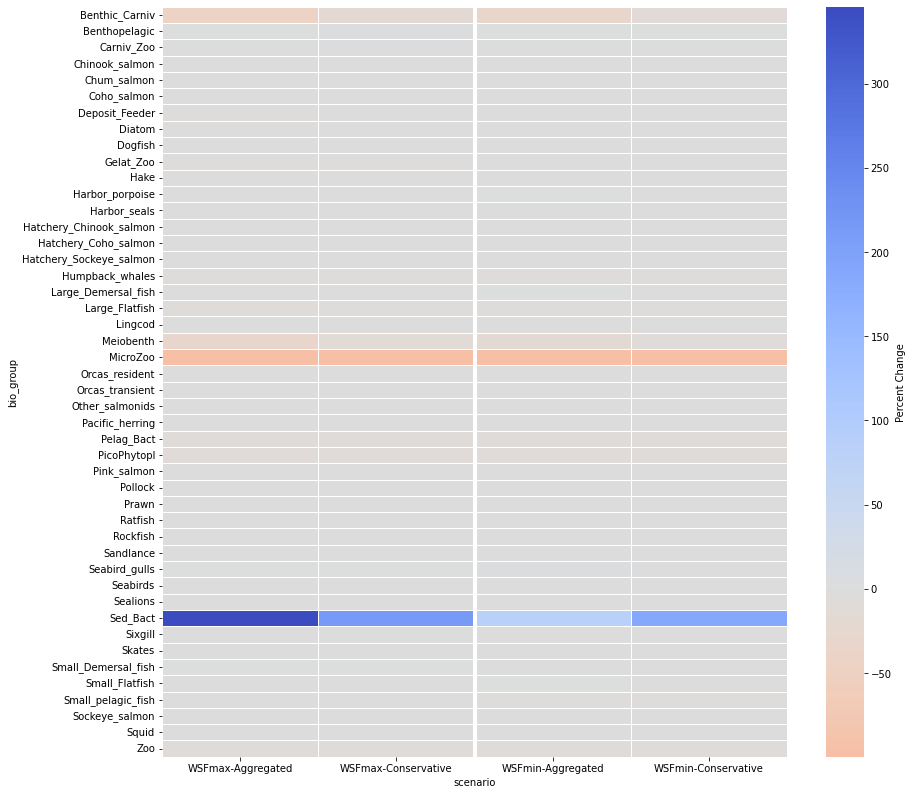

In [12]:
heatmap_pelagic(groups.all_pelagic, location=Turn_Point)

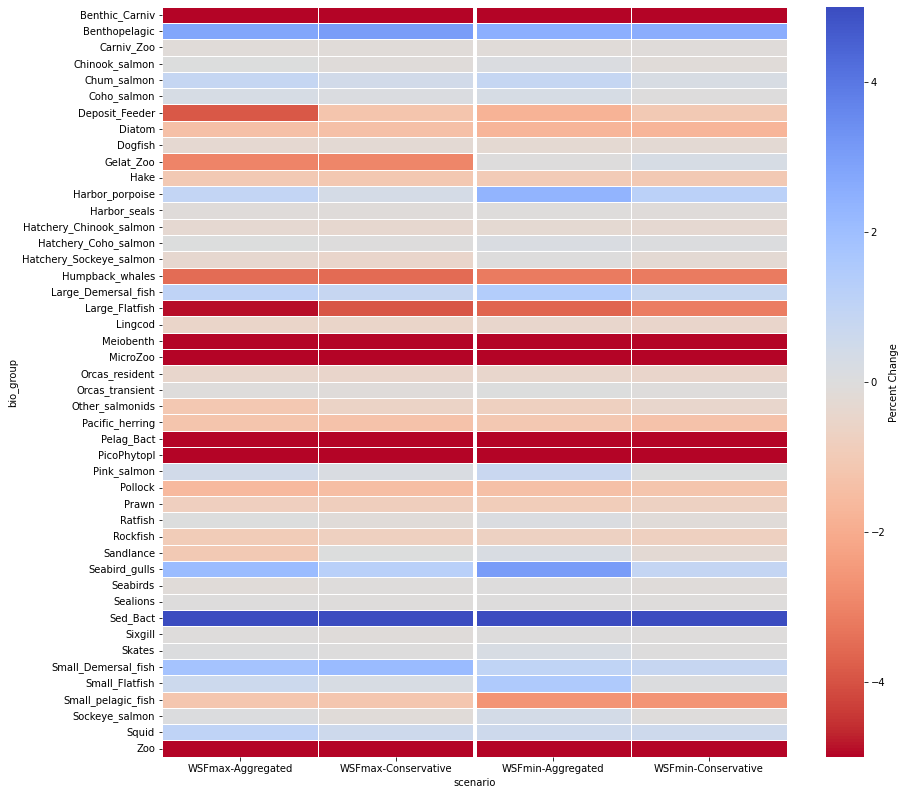

In [14]:
df = pd.read_csv("/ocean/rlovindeer/MOAD/analysis-raisha/SSmodel_outputs/Spills/MPRI1/heatmap-pelagic-TP-WSF.csv")
df_pivot = df.pivot_table(index='bio_group', 
                        columns='scenario', 
                        values='percent_change', 
                        )

#sns.heatmap(df_pivot, annot=False, cmap='coolwarm_r', center=0)
plt.figure(figsize=(14, len(df_pivot)*0.3))
ax = sns.heatmap(df_pivot, annot=False, cmap='coolwarm_r', center=0, vmin=-5, vmax=5,
    linewidths=0.5,
    #linecolor='gray',
    cbar_kws={'label': 'Percent Change'})
location_boundaries = []
prev_loc = None
for i, col in enumerate(df_pivot.columns):
    loc = col.split('-')[0]
    if prev_loc is not None and loc != prev_loc:
        location_boundaries.append(i)
    prev_loc = loc

for x in location_boundaries:
    ax.vlines(x, *ax.get_ylim(), colors='white', linewidth=4)

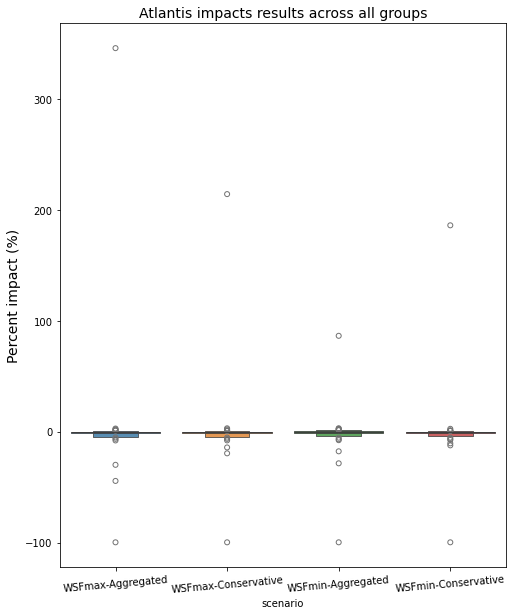

In [17]:
plt.figure(figsize=(8, 10))
ax = sns.boxenplot(df_pivot) 
plt.ylabel('Percent impact (%)', fontsize = 14)
plt.title('Atlantis impacts results across all groups', fontsize = 14)
plt.xticks(rotation=5);

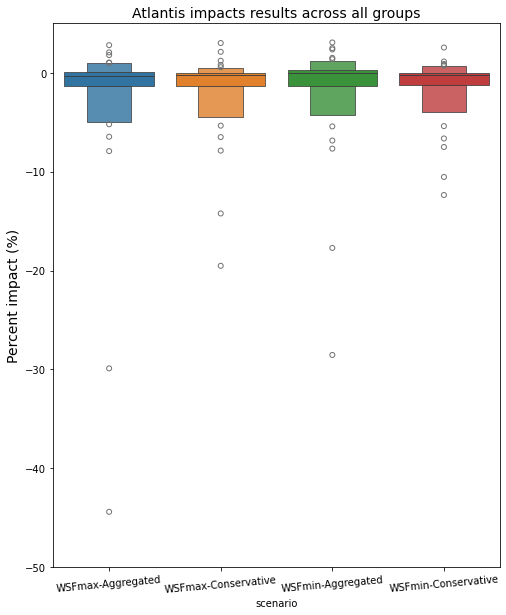

In [30]:
plt.figure(figsize=(8, 10))
ax = sns.boxenplot(df_pivot) 
plt.ylim(-50, 5)
plt.ylabel('Percent impact (%)', fontsize = 14)
plt.title('Atlantis impacts results across all groups', fontsize = 14)
plt.xticks(rotation=5);

In [18]:
max_min_c = df_pivot['WSFmax-Conservative'] - df_pivot['WSFmin-Conservative']
max_min_a = df_pivot['WSFmax-Aggregated'] - df_pivot['WSFmin-Aggregated']
agg_cons_h = df_pivot['WSFmax-Aggregated'] - df_pivot['WSFmax-Conservative']
agg_con_l = df_pivot['WSFmin-Aggregated'] - df_pivot['WSFmin-Conservative']

In [19]:
diff_results = {'Solubility max-min_a': max_min_a,
                'Solubility max-min_c': max_min_c,
                'PAH agg-cons_hs': agg_cons_h,
                'PAH agg-cons_ls': agg_con_l,}


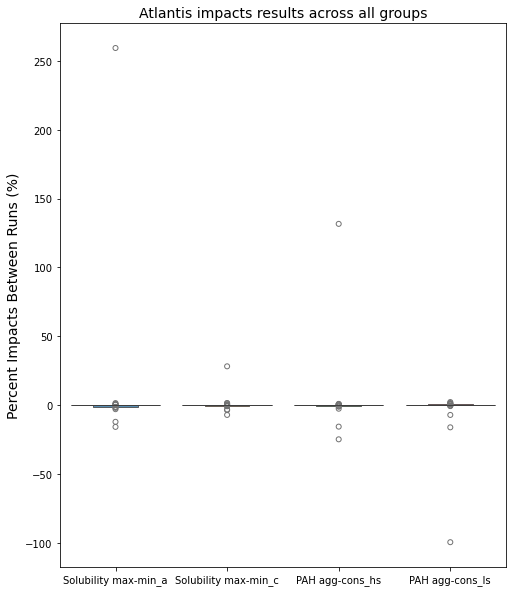

In [20]:
plt.figure(figsize=(8, 10))
ax = sns.boxenplot(diff_results) 
plt.ylabel('Percent Impacts Between Runs (%)', fontsize = 14)
plt.title('Atlantis impacts results across all groups', fontsize = 14);


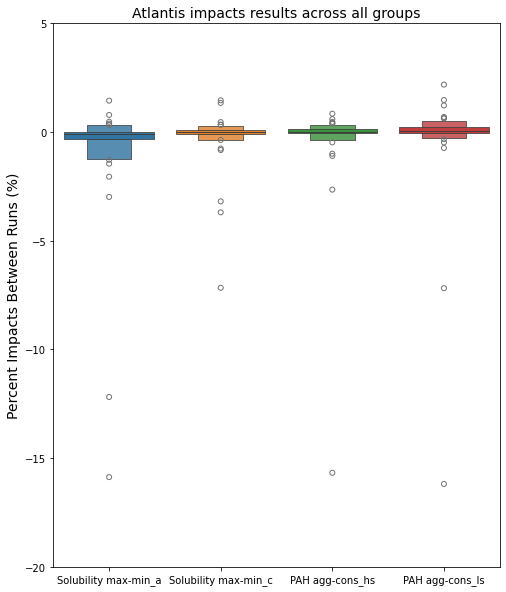

In [29]:
plt.figure(figsize=(8, 10))
ax = sns.boxenplot(diff_results) 
plt.ylim(-20, 5)
plt.ylabel('Percent Impacts Between Runs (%)', fontsize = 14)
plt.title('Atlantis impacts results across all groups', fontsize = 14);

In [22]:
max_min_a

bio_group
Benthic_Carniv             -15.870683
Benthopelagic                0.294595
Carniv_Zoo                  -0.006542
Chinook_salmon              -0.078797
Chum_salmon                  0.000347
Coho_salmon                 -0.000780
Deposit_Feeder              -2.055157
Diatom                       0.326625
Dogfish                     -0.056674
Gelat_Zoo                   -2.984333
Hake                        -0.074805
Harbor_porpoise             -1.455144
Harbor_seals                -0.014758
Hatchery_Chinook_salmon     -0.059711
Hatchery_Coho_salmon        -0.115678
Hatchery_Sockeye_salmon     -0.357177
Humpback_whales             -0.315908
Large_Demersal_fish         -0.361445
Large_Flatfish              -1.277049
Lingcod                     -0.071681
Meiobenth                  -12.185407
MicroZoo                     0.000553
Orcas_resident              -0.025249
Orcas_transient             -0.072414
Other_salmonids             -0.323520
Pacific_herring             -0.136368
Pe

In [23]:
max_min_c

bio_group
Benthic_Carniv             -7.163911
Benthopelagic               0.456990
Carniv_Zoo                 -0.018945
Chinook_salmon              0.025173
Chum_salmon                 0.216714
Coho_salmon                 0.147296
Deposit_Feeder             -0.141455
Diatom                      0.339179
Dogfish                    -0.026781
Gelat_Zoo                  -3.189474
Hake                       -0.066545
Harbor_porpoise            -0.827211
Harbor_seals                0.016391
Hatchery_Chinook_salmon    -0.039436
Hatchery_Coho_salmon       -0.084213
Hatchery_Sockeye_salmon    -0.226456
Humpback_whales            -0.349661
Large_Demersal_fish         0.053522
Large_Flatfish             -0.758949
Lingcod                    -0.040478
Meiobenth                  -3.694836
MicroZoo                    0.000618
Orcas_resident              0.004866
Orcas_transient            -0.023021
Other_salmonids            -0.176921
Pacific_herring            -0.010436
Pelag_Bact                  

In [24]:
agg_cons_h

bio_group
Benthic_Carniv             -24.892055
Benthopelagic               -0.215092
Carniv_Zoo                  -0.007999
Chinook_salmon               0.102736
Chum_salmon                  0.413011
Coho_salmon                  0.141071
Deposit_Feeder              -2.648522
Diatom                      -0.002196
Dogfish                     -0.069586
Gelat_Zoo                   -0.047621
Hake                         0.051828
Harbor_porpoise              0.593919
Harbor_seals                 0.012532
Hatchery_Chinook_salmon      0.021197
Hatchery_Coho_salmon         0.034296
Hatchery_Sockeye_salmon      0.106426
Humpback_whales              0.017486
Large_Demersal_fish          0.223583
Large_Flatfish              -0.996844
Lingcod                      0.012178
Meiobenth                  -15.673109
MicroZoo                    -0.000101
Orcas_resident               0.015684
Orcas_transient              0.046076
Other_salmonids             -0.478054
Pacific_herring              0.081437
Pe

In [25]:
agg_con_l

bio_group
Benthic_Carniv            -16.185283
Benthopelagic              -0.052697
Carniv_Zoo                 -0.020401
Chinook_salmon              0.206706
Chum_salmon                 0.629379
Coho_salmon                 0.289147
Deposit_Feeder             -0.734820
Diatom                      0.010358
Dogfish                    -0.039693
Gelat_Zoo                  -0.252762
Hake                        0.060088
Harbor_porpoise             1.221852
Harbor_seals                0.043681
Hatchery_Chinook_salmon     0.041473
Hatchery_Coho_salmon        0.065761
Hatchery_Sockeye_salmon     0.237147
Humpback_whales            -0.016267
Large_Demersal_fish         0.638550
Large_Flatfish             -0.478744
Lingcod                     0.043381
Meiobenth                  -7.182538
MicroZoo                   -0.000035
Orcas_resident              0.045799
Orcas_transient             0.095468
Other_salmonids            -0.331456
Pacific_herring             0.207369
Pelag_Bact                 -

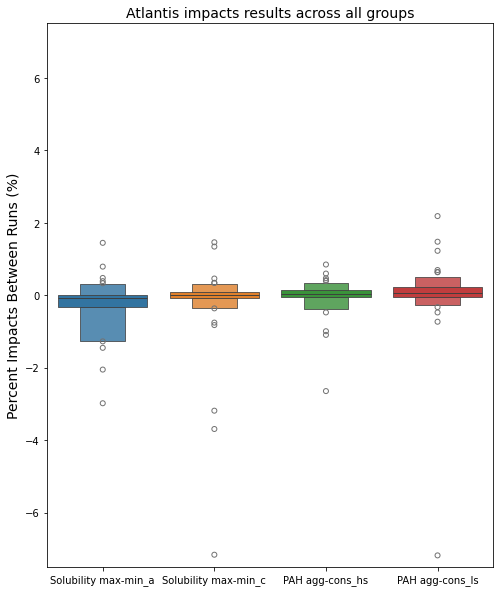

In [26]:
plt.figure(figsize=(8, 10))
ax = sns.boxenplot(diff_results) 
plt.ylim(-7.5, 7.5)
plt.ylabel('Percent Impacts Between Runs (%)', fontsize = 14)
plt.title('Atlantis impacts results across all groups', fontsize = 14);

### PAH Concentrations in Habitat

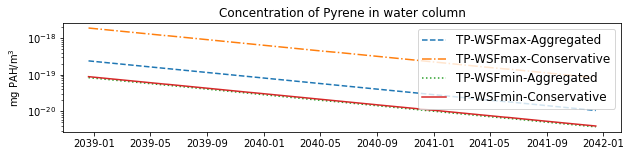

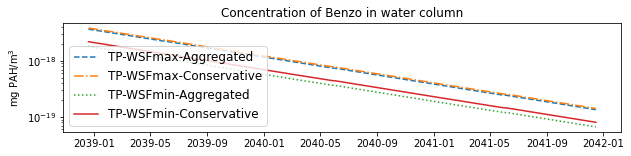

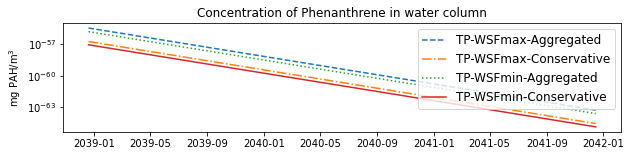

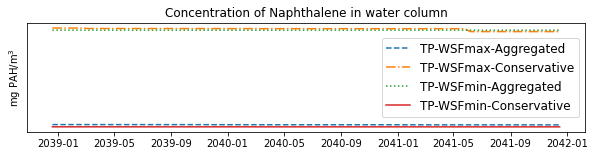

In [31]:
for pah in groups.pahs:
    fig, ax = plt.subplots(figsize = (10,2))
    for scenario, name in zip(scenario_datasets,scenario_names):
        contam_tbl = scenario.variables[str(pah)][start:end,:,0:6]
        contam_tb = contam_tbl.sum(axis=2)
        contam_t = contam_tb.sum(axis=1)
        # if 'AP' in name:
        #     hex_colour = '#863092'
        # elif 'TP' in name:
        #     hex_colour = '#6DB48E'
        # elif 'EB' in name:
        #     hex_colour = '#2F61A4'
        # elif 'JF' in name:
        #     hex_colour = '#A27170'
        ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles)) #color=hex_colour,
    ax.set_title('Concentration of '+ pah +' in water column', fontsize = 12)
    ax.set_ylabel('mg PAH/m$^3$')
    ax.legend(scenario_names, fontsize=12, ncol=1) #, bbox_to_anchor=(1.05, 1)) #loc='upper center', 

### PAH in biological groups

In [32]:
def plot_pelagic_pah(species,pah, scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None,ncol=1):
        fig, ax = plt.subplots(figsize = (8,2))
        for scenario, name in zip(scenario_datasets,scenario_names):
            contam_tb = scenario.variables[species+'_'+str(pah)][start:end,boxes,0:6]
            contam_t = contam_tb.sum(axis=(1,2))
            if 'AP' in name:
                hex_colour = '#863092'
            elif 'TP' in name:
                hex_colour = '#6DB48E'
            elif 'EB' in name:
                hex_colour = '#2F61A4'
            elif 'JF' in name:
                hex_colour = '#A27170'
            ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles)) #color=hex_colour, 
        ax.set_title('Concentration of '+ pah +' in '+ species, fontsize = 12)
        ax.set_ylabel('mg PAH/m$^3$')
        ax.legend(scenario_names, fontsize=12, ncol=ncol,bbox_to_anchor=(1.05, 1)); #loc='upper left', , loc='upper center', 

In [33]:
def plot_benthic_pah(species,pah, scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None,ncol=1):
        fig, ax = plt.subplots(figsize = (8,2))
        for scenario, name in zip(scenario_datasets,scenario_names):
            contam_tb = scenario.variables[species+'_'+str(pah)][start:end,boxes]
            contam_t = contam_tb.sum(axis=(1))
            if 'AP' in name:
                hex_colour = '#863092'
            elif 'TP' in name:
                hex_colour = '#6DB48E'
            elif 'EB' in name:
                hex_colour = '#2F61A4'
            elif 'JF' in name:
                hex_colour = '#A27170'
            ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles)) #color=hex_colour, 
        ax.set_title('Concentration of '+ pah +' in '+ species, fontsize = 12)
        ax.set_ylabel('mg PAH/m$^3$')
        ax.legend(scenario_names, fontsize=12, ncol=ncol,bbox_to_anchor=(1.05, 1)); #loc='upper left', bbox_to_anchor=(1.05, 1), loc='upper center', 

In [34]:
def plot_vertebrate_pah(species,pah, scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None,ncol=1):
        fig, ax = plt.subplots(figsize = (8,2))
        for scenario, name in zip(scenario_datasets,scenario_names):
            contam_tbl = 0
            for cohort in range (1, groups.cohorts[species]+1):
                contam_tbl = contam_tbl + scenario.variables[species+str(cohort)+'_'+str(pah)][start:end,boxes,0:6]
            contam_t = contam_tbl.sum(axis=(1,2))
            if 'AP' in name:
                hex_colour = '#863092'
            elif 'TP' in name:
                hex_colour = '#6DB48E'
            elif 'EB' in name:
                hex_colour = '#2F61A4'
            elif 'JF' in name:
                hex_colour = '#A27170'
            ax.semilogy(scenario.t[start:end], contam_t, linestyle=next(line_styles)) #color=hex_colour, 
        ax.set_title('Concentration of '+ pah +' in '+ species, fontsize = 12)
        ax.set_ylabel('mg PAH/m$^3$')
        ax.legend(scenario_names, fontsize=12, ncol=ncol,bbox_to_anchor=(1.05, 1)); #loc='upper left', bbox_to_anchor=(1.05, 1), loc='upper center', 

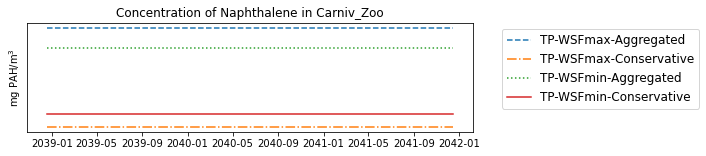

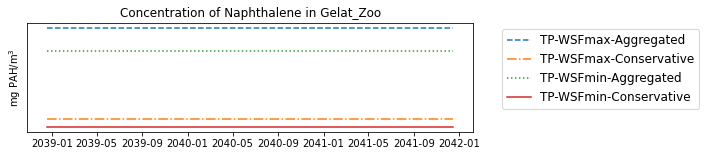

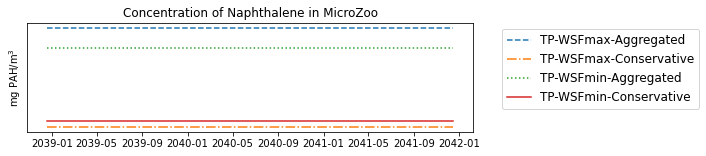

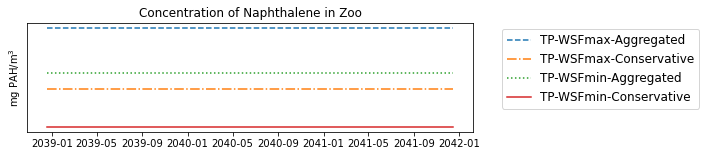

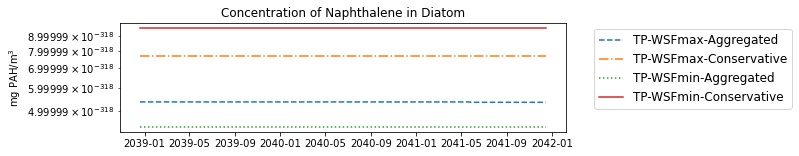

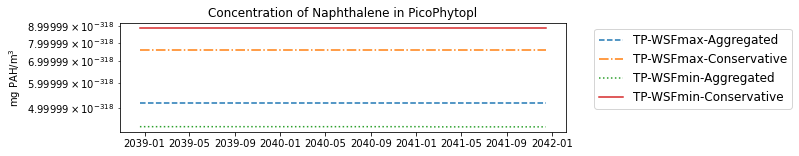

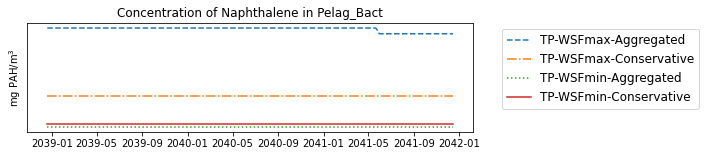

In [35]:
for species in groups.plankton:
    plot_pelagic_pah(groups.plankton[species], 'Naphthalene', ncol=1)

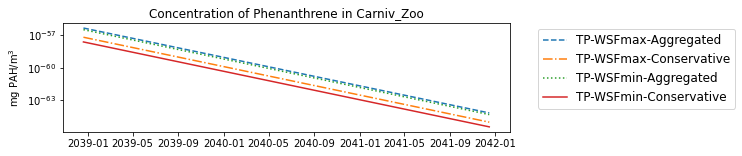

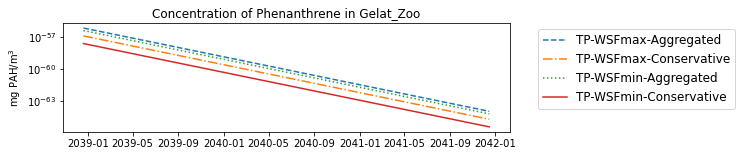

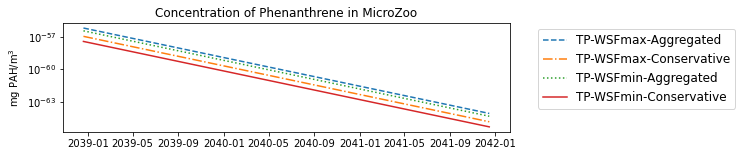

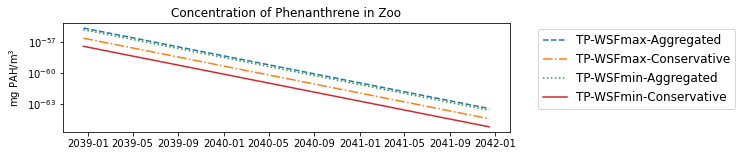

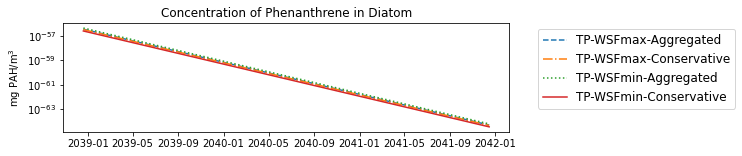

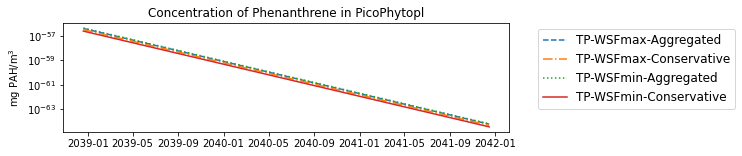

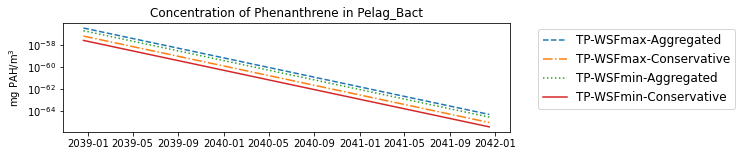

In [36]:
for species in groups.plankton:
    plot_pelagic_pah(groups.plankton[species], 'Phenanthrene', ncol=1)

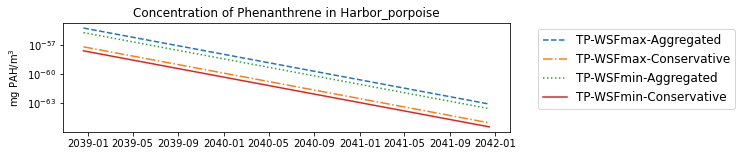

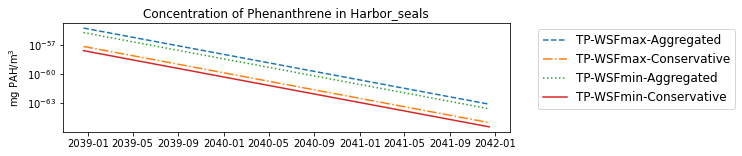

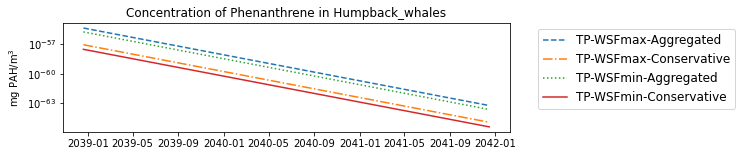

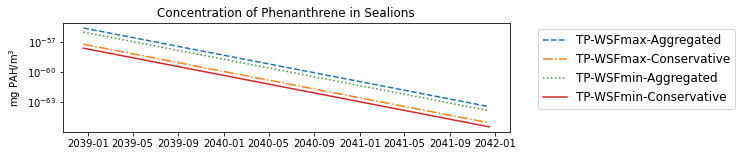

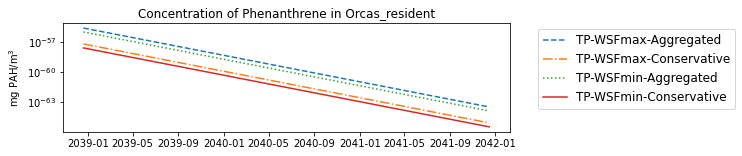

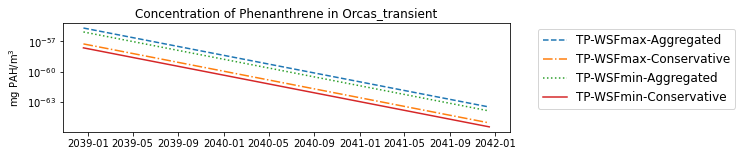

In [37]:
for species in groups.mammals:
    plot_vertebrate_pah(groups.mammals[species], 'Phenanthrene')

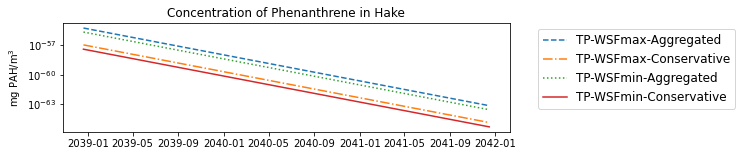

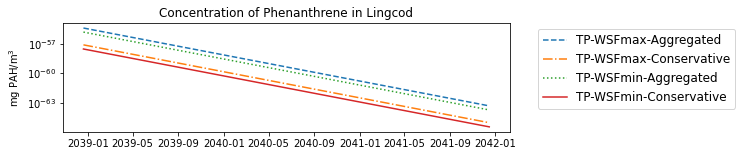

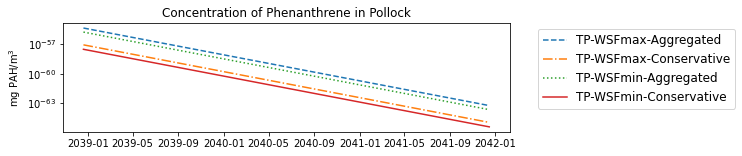

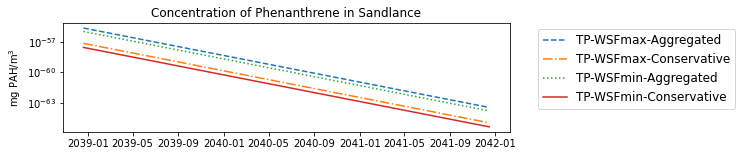

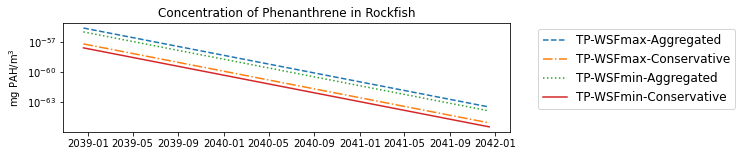

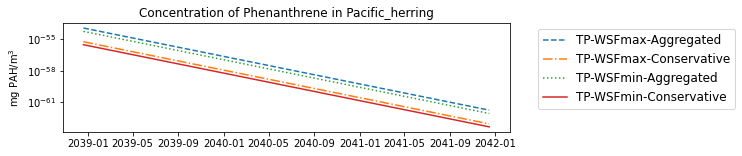

In [38]:
for species in groups.named_fish:
    plot_vertebrate_pah(groups.named_fish[species],'Phenanthrene')

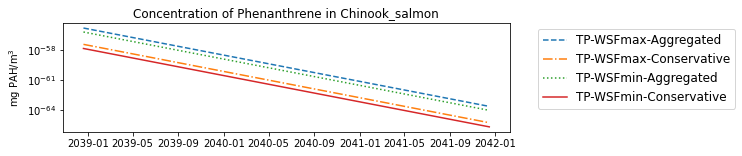

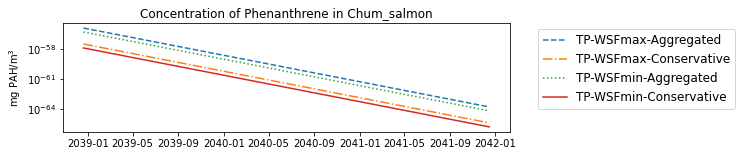

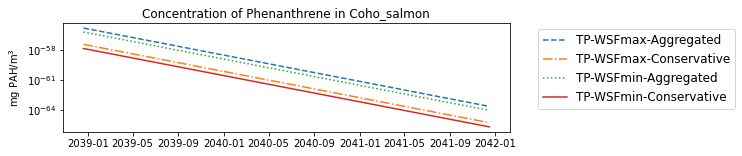

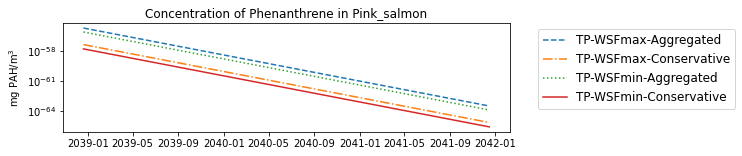

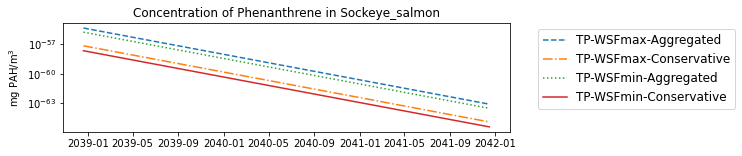

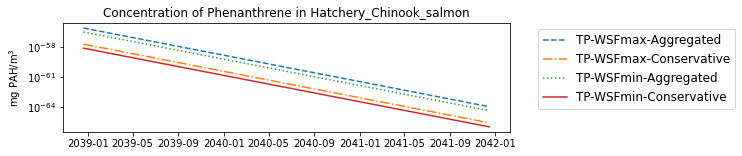

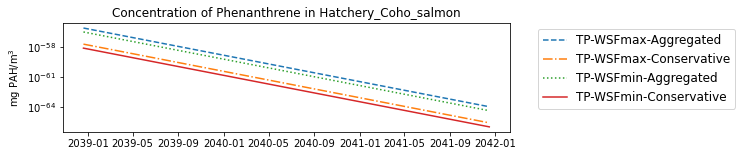

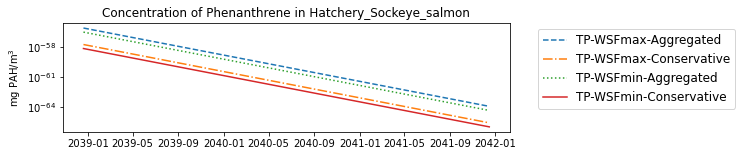

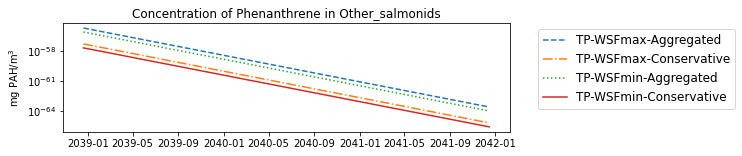

In [39]:
for species in groups.salmon:
    plot_vertebrate_pah(groups.salmon[species],'Phenanthrene')

### Impact results

In [40]:
def compare_scenario_pelagic(species, scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None,ncol=1): 
    
    names = ['control']

    fig, ax = plt.subplots(figsize = (8,2))

    pelagic_control_tbl = np.ma.filled(control.variables[species+'_N'][start:end,boxes,0:6], np.nan)
    pelagic_control = pelagic_control_tbl.sum(axis=(1,2))
    control_ratio = (pelagic_control / pelagic_control-1)*100
    ax.plot(control.t[start:end], control_ratio, 'k', linewidth = 2)

    for scenario, name in zip(scenario_datasets, scenario_names):
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        
        names.append(name)

        pelagic_oiled_tbl = np.ma.filled(scenario.variables[species+'_N'][start:end,boxes,0:6], np.nan)
        pelagic_oiled = pelagic_oiled_tbl.sum(axis=(1,2))
        ratio = (pelagic_oiled / pelagic_control-1)*100
        ax.plot(scenario.t[start:end], ratio, linewidth = 2, linestyle=next(line_styles)) #color=hex_colour,
    ax.fill_between(scenario.t[start:end], -sensitivity[species], sensitivity[species],
        color='grey', alpha=0.3, label='Model Sensitivity')

    plt.ylabel('Percent (%) change', fontsize=12)
    ax.set_title(species)
    ax.set_ylim([y_min, y_max])
    ax.legend(names, fontsize=12, ncol=ncol,bbox_to_anchor=(1.05, 1)); #bbox_to_anchor=(1.05, 1)

In [41]:
def compare_scenario_phytoplankton(scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None,ncol=1): 
    
    names = ['control']

    fig, ax = plt.subplots(figsize = (8,2)) #14,5

    pelagic_control_tbl = np.ma.filled(control.variables['Diatom_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(control.variables['PicoPhytopl_N'][start:end,boxes,0:6], np.nan)
    pelagic_control = pelagic_control_tbl.sum(axis=(1,2))
    control_ratio = (pelagic_control / pelagic_control-1)*100
    ax.plot(control.t[start:end], control_ratio, 'k', linewidth = 2)

    for scenario, name in zip(scenario_datasets, scenario_names):
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        
        names.append(name)

        pelagic_oiled_tbl = np.ma.filled(scenario.variables['Diatom_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(scenario.variables['PicoPhytopl_N'][start:end,boxes,0:6], np.nan)
        pelagic_oiled = pelagic_oiled_tbl.sum(axis=(1,2))
        ratio = (pelagic_oiled / pelagic_control-1)*100
        ax.plot(scenario.t[start:end], ratio, linewidth = 2, linestyle=next(line_styles)) #color=hex_colour, 
    ax.fill_between(scenario.t[start:end], -sensitivity['Phytoplankton'], sensitivity['Phytoplankton'],
        color='grey', alpha=0.3, label='Model Sensitivity')
    
    plt.ylabel('Percent (%) change', fontsize=12)
    ax.set_title('Phytoplankton')
    ax.set_ylim([y_min, y_max])
    ax.legend(names, fontsize=12, bbox_to_anchor=(1.05, 1),ncol=ncol); #bbox_to_anchor=(1.05, 1)

In [42]:
def compare_scenario_zooplankton(scenario_datasets=scenario_datasets, scenario_names=scenario_names, boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None,ncol=1): 
    
    names = ['control']

    fig, ax = plt.subplots(figsize = (8,2))

    pelagic_control_tbl = np.ma.filled(control.variables['MicroZoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(control.variables['Zoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(control.variables['Carniv_Zoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(control.variables['Gelat_Zoo_N'][start:end,boxes,0:6], np.nan)
    pelagic_control = pelagic_control_tbl.sum(axis=(1,2))
    control_ratio = (pelagic_control / pelagic_control-1)*100
    ax.plot(control.t[start:end], control_ratio, 'k', linewidth = 2)

    for scenario, name in zip(scenario_datasets, scenario_names):
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        
        names.append(name)

        pelagic_oiled_tbl = np.ma.filled(scenario.variables['MicroZoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(scenario.variables['Zoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(scenario.variables['Carniv_Zoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(scenario.variables['Gelat_Zoo_N'][start:end,boxes,0:6], np.nan)
        pelagic_oiled = pelagic_oiled_tbl.sum(axis=(1,2))
        ratio = (pelagic_oiled / pelagic_control-1)*100
        ax.plot(scenario.t[start:end], ratio, linewidth = 2, linestyle=next(line_styles)) #color=hex_colour, 
    ax.fill_between(scenario.t[start:end], -sensitivity['Zooplankton'], sensitivity['Zooplankton'],
        color='grey', alpha=0.3, label='Model Sensitivity')
    
    plt.ylabel('Percent (%) change', fontsize=12)
    ax.set_title('Zooplankton')
    ax.set_ylim([y_min, y_max])
    ax.legend(names, fontsize=12, bbox_to_anchor=(1.05, 1),ncol=ncol); #bbox_to_anchor=(1.05, 1), loc='lower right'

In [43]:
def plot_scenario_biomass_phytoplankton(scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None, ncol=1, alpha=0.6, savepath=None): 
    
    names = ['control']

    fig, ax = plt.subplots(figsize = (8,2))

    pelagic_control_tbl = np.ma.filled(control.variables['Diatom_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(control.variables['PicoPhytopl_N'][start:end,boxes,0:6], np.nan)
    pelagic_control = pelagic_control_tbl.sum(axis=(1,2))
    #control_ratio = (pelagic_control / pelagic_control-1)*100
    ax.plot(control.t[start:end], pelagic_control, 'k', linewidth = 2)

    for scenario, name in zip(scenario_datasets, scenario_names):
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        
        names.append(name)

        pelagic_oiled_tbl = np.ma.filled(scenario.variables['Diatom_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(scenario.variables['PicoPhytopl_N'][start:end,boxes,0:6], np.nan)
        pelagic_oiled = pelagic_oiled_tbl.sum(axis=(1,2))
        #ratio = (pelagic_oiled / pelagic_control-1)*100
        ax.plot(scenario.t[start:end], pelagic_oiled, linewidth = 2, alpha=alpha, linestyle=next(line_styles)) #color=hex_colour, 
    #ax.fill_between(scenario.t[start:end], -0.3, 0.3,
        #color='grey', alpha=0.3, label='Model Sensitivity')
    
    plt.ylabel('Biomass (mg N)', fontsize=16)
    ax.set_title('Phytoplankton', fontsize=16)
    ax.set_ylim([y_min, y_max])
    ylabels = ax.get_yticklabels()
    xlabels = ax.get_xticklabels()
    plt.setp(xlabels, fontsize=14)
    plt.setp(ylabels, fontsize=14)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.grid(True, alpha=1)
    ax.legend(names, bbox_to_anchor=(1, 1.05), fontsize=14, ncol=ncol) #bbox_to_anchor=(1.05, 1)); #ncol=ncol
    

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')


In [44]:
def plot_scenario_biomass_zooplankton(scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None, ncol=1, alpha=0.6, savepath=None): 
    
    names = ['control']

    fig, ax = plt.subplots(figsize = (8,2))

    pelagic_control_tbl = np.ma.filled(control.variables['MicroZoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(control.variables['Zoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(control.variables['Carniv_Zoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(control.variables['Gelat_Zoo_N'][start:end,boxes,0:6], np.nan)
    pelagic_control = pelagic_control_tbl.sum(axis=(1,2))
    #control_ratio = (pelagic_control / pelagic_control-1)*100
    ax.plot(control.t[start:end], pelagic_control, 'k', linewidth = 2)

    for scenario, name in zip(scenario_datasets, scenario_names):
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        
        names.append(name)

        pelagic_oiled_tbl = np.ma.filled(scenario.variables['MicroZoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(scenario.variables['Zoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(scenario.variables['Carniv_Zoo_N'][start:end,boxes,0:6], np.nan) + np.ma.filled(scenario.variables['Gelat_Zoo_N'][start:end,boxes,0:6], np.nan)
        pelagic_oiled = pelagic_oiled_tbl.sum(axis=(1,2))
        #ratio = (pelagic_oiled / pelagic_control-1)*100
        ax.plot(scenario.t[start:end], pelagic_oiled, linewidth = 2, alpha=alpha, linestyle=next(line_styles)) #color=hex_colour, 
    #ax.fill_between(scenario.t[start:end], -0.3, 0.3,
        #color='grey', alpha=0.3, label='Model Sensitivity')
    
    #plt.ylabel('Biomass (mg N)', fontsize=16)
    ax.set_title('Zooplankton', fontsize=16)
    ax.set_ylim([y_min, y_max])
    ylabels = ax.get_yticklabels()
    xlabels = ax.get_xticklabels()
    plt.setp(xlabels, fontsize=14)
    plt.setp(ylabels, fontsize=14)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator())
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(ax.xaxis.get_major_locator()))
    ax.grid(True, alpha=1)
    ax.legend(names, fontsize=14, bbox_to_anchor=(1.05, 1), ncol=ncol) #bbox_to_anchor=(1, 1.05),  bbox_to_anchor=(1.05, 1)); #ncol=ncol 

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches='tight')

In [45]:
def compare_scenario_vertebrates(bio_group, scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None): 
    
    names = ['control']

    fig, ax = plt.subplots(figsize = (8,2)) #14,5

    pelagic_control_tbl = np.ma.filled(control.variables[bio_group + '_N'][start:end,boxes,0:6], np.nan)
    pelagic_control = pelagic_control_tbl.sum(axis=(1,2))
    control_ratio = (pelagic_control / pelagic_control-1)*100
    ax.plot(control.t[start:end], control_ratio, 'k', linewidth = 2)

    for scenario, name in zip(scenario_datasets, scenario_names):
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        
        names.append(name)

        sum_ratio = 0
        
        numCohorts = groups.cohorts[bio_group]
        for cohort in range (1, numCohorts+1):

            new_species = bio_group + str(cohort)
        
            o_numbers_tbl = np.ma.filled(scenario.variables[new_species + '_Nums'][start:end, boxes, 0:6], np.nan)
            o_structuralN_tbl = np.ma.filled(scenario.variables[new_species +'_StructN'][start:end, boxes, 0:6], np.nan)
            o_reservedN_tbl = np.ma.filled(scenario.variables[new_species +'_ResN'][start:end, boxes, 0:6], np.nan)

            c_numbers_tbl = np.ma.filled(control.variables[new_species + '_Nums'][start:end, boxes, 0:6], np.nan)
            c_structuralN_tbl = np.ma.filled(control.variables[new_species +'_StructN'][start:end, boxes, 0:6], np.nan)
            c_reservedN_tbl = np.ma.filled(control.variables[new_species +'_ResN'][start:end, boxes, 0:6], np.nan)

            o_weightatage_tbl = (o_structuralN_tbl + o_reservedN_tbl) * o_numbers_tbl 
            o_weightatage = o_weightatage_tbl.sum(axis=(1,2))

            c_weightatage_tbl = (c_structuralN_tbl + c_reservedN_tbl) * c_numbers_tbl 
            c_weightatage = c_weightatage_tbl.sum(axis=(1,2))

            #difference = o_weightatage_tb.sum(axis=1) - c_weightatage_tb.sum(axis=1) 
            ratio = (o_weightatage / c_weightatage - 1) * 100
            #print(ratio)
            sum_ratio = sum_ratio + ratio

        ax.plot(scenario.t[start:end], sum_ratio/numCohorts, linewidth = 2, linestyle=next(line_styles)) #color=hex_colour, 
    ax.fill_between(scenario.t[start:end], -sensitivity[bio_group], sensitivity[bio_group],
        color='grey', alpha=0.3, label='Model Sensitivity')
    
    plt.ylabel('Percent (%) change', fontsize=12)
    ax.set_title(bio_group)
    ax.set_ylim([y_min, y_max])
    ax.legend(names, fontsize=12, bbox_to_anchor=(1.05, 1), ncol=1); #bbox_to_anchor=(1.05, 1), loc='lower right'

In [46]:
def compare_scenarios_benthic_N(species, scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None): 

    names = ['control']

    fig, ax = plt.subplots(figsize = (8,2))

    pelagic_control = np.ma.filled(control.variables[species + '_N'][start:end,boxes], np.nan)
    pelagic_control = pelagic_control.sum(axis=1)
    control_ratio = (pelagic_control / pelagic_control-1)*100
    ax.plot(control.t[start:end], control_ratio, 'k', linewidth = 2)

    for scenario, name in zip(scenario_datasets, scenario_names):
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        
        names.append(name)

        pelagic_oiled = np.ma.filled(scenario.variables[species + '_N'][start:end,boxes], np.nan) # tonnes
        pelagic_oiled = pelagic_oiled.sum(axis=1) 
        ratio = (pelagic_oiled / pelagic_control-1)*100
        ax.plot(scenario.t[start:end], ratio, linewidth = 2, linestyle=next(line_styles)) #color=hex_colour, 
    ax.fill_between(scenario.t[start:end], -sensitivity[species], sensitivity[species],
        color='grey', alpha=0.3, label='Model Sensitivity')
    
    plt.ylabel('Percent (%) change', fontsize=12)
    ax.set_title(species)
    ax.set_ylim([y_min, y_max])
    ax.legend(names, bbox_to_anchor=(1.05, 1), fontsize=12, ncol=1); #bbox_to_anchor=(1.05, 1), 

In [47]:
def plot_scenarios_biomass_benthic_N(species, scenario_datasets=scenario_datasets, scenario_names=scenario_names,boxes=groups.salish_sea, start=start, end=end, y_min=None, y_max=None): 

    names = ['control']

    fig, ax = plt.subplots(figsize = (8,2))

    pelagic_control = np.ma.filled(control.variables[species + '_N'][start:end,boxes], np.nan)
    pelagic_control = pelagic_control.sum(axis=1)
    ax.plot(control.t[start:end], pelagic_control, 'k', linewidth = 2)

    for scenario, name in zip(scenario_datasets, scenario_names):
        if 'AP' in name:
            hex_colour = '#863092'
        elif 'TP' in name:
            hex_colour = '#6DB48E'
        elif 'EB' in name:
            hex_colour = '#2F61A4'
        elif 'JF' in name:
            hex_colour = '#A27170'
        
        names.append(name)

        pelagic_oiled = np.ma.filled(scenario.variables[species + '_N'][start:end,boxes], np.nan) # tonnes
        pelagic_oiled = pelagic_oiled.sum(axis=1) 
        ax.plot(scenario.t[start:end], pelagic_oiled, linewidth = 2, linestyle=next(line_styles)) #color=hex_colour,
    
    plt.ylabel('Biomass (mg N)', fontsize=12)
    ax.set_title(species)
    ax.set_ylim([y_min, y_max])
    ax.legend(names, bbox_to_anchor=(1.05, 1), fontsize=12); #bbox_to_anchor=(1.05, 1), 

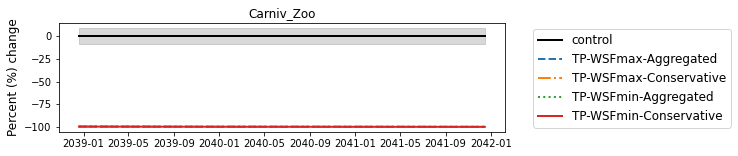

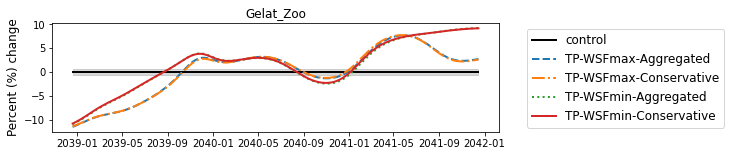

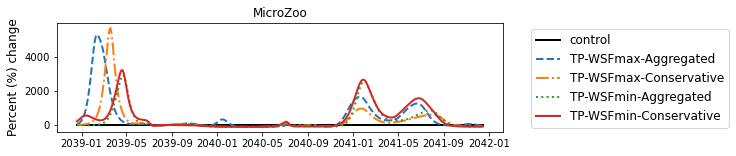

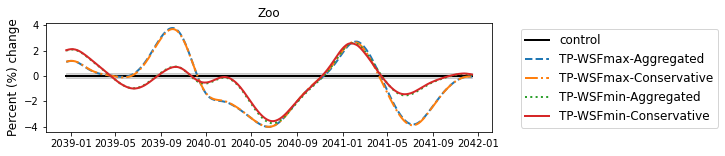

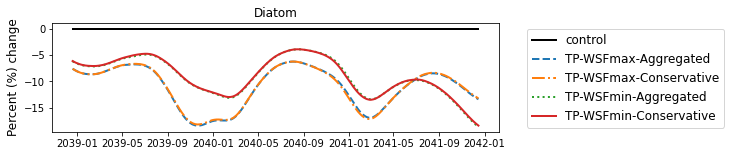

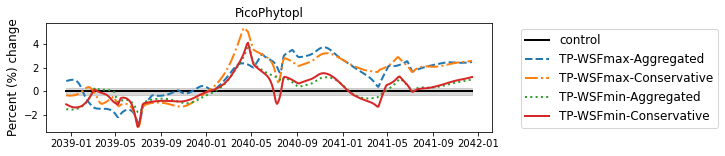

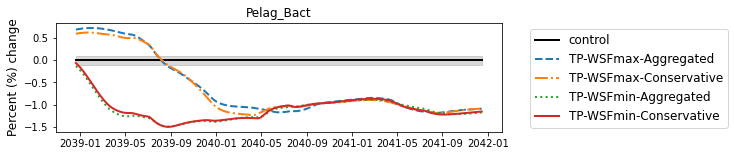

In [48]:
for species in groups.plankton:
    compare_scenario_pelagic(groups.plankton[species])

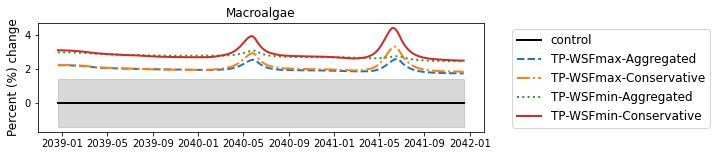

In [49]:
compare_scenarios_benthic_N('Macroalgae')

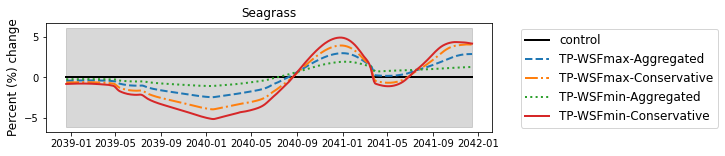

In [50]:
compare_scenarios_benthic_N('Seagrass')

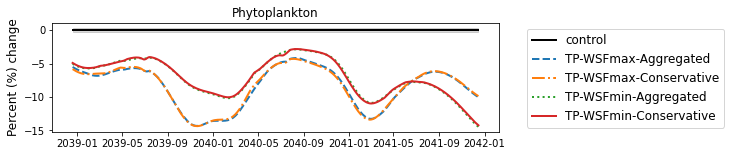

In [51]:
compare_scenario_phytoplankton()

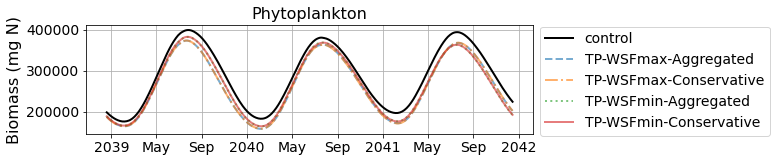

In [52]:
plot_scenario_biomass_phytoplankton()

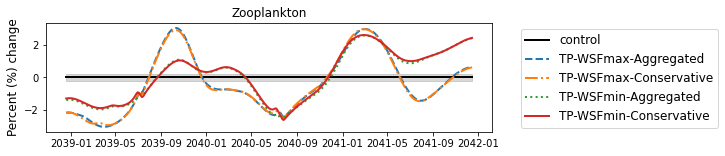

In [53]:
compare_scenario_zooplankton()

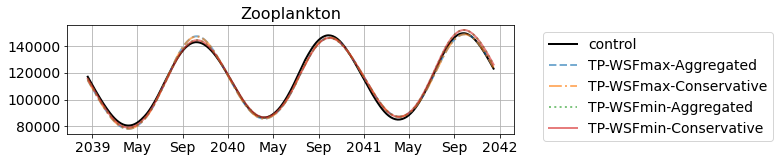

In [54]:
plot_scenario_biomass_zooplankton()

In [55]:
for species in groups.salmon:
    print(groups.salmon[species])

Chinook_salmon
Chum_salmon
Coho_salmon
Pink_salmon
Sockeye_salmon
Hatchery_Chinook_salmon
Hatchery_Coho_salmon
Hatchery_Sockeye_salmon
Other_salmonids


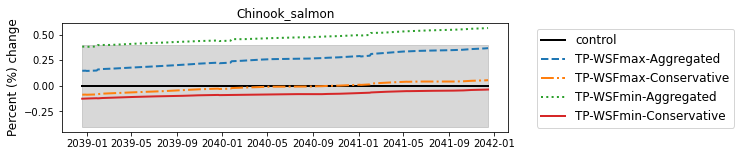

In [56]:
compare_scenario_vertebrates('Chinook_salmon')

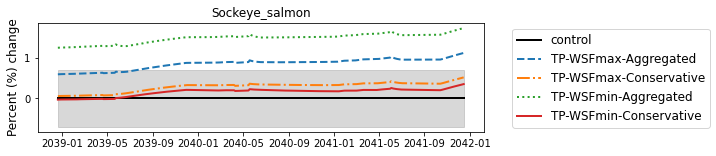

In [57]:
compare_scenario_vertebrates('Sockeye_salmon')

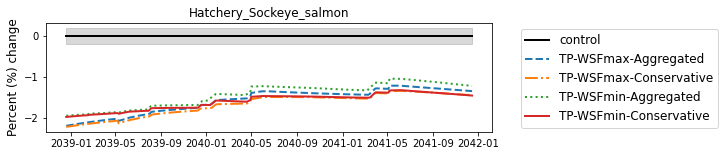

In [58]:
compare_scenario_vertebrates('Hatchery_Sockeye_salmon')

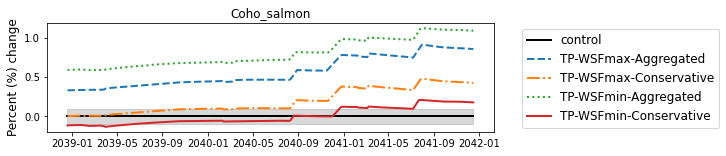

In [59]:
compare_scenario_vertebrates('Coho_salmon')

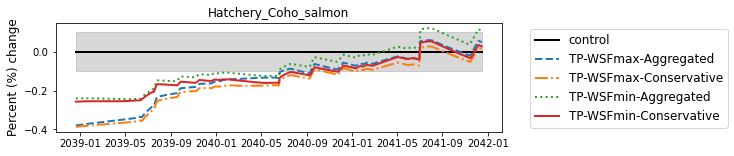

In [60]:
compare_scenario_vertebrates('Hatchery_Coho_salmon')

In [61]:
for species in groups.mammals:
    print(groups.mammals[species])

Harbor_porpoise
Harbor_seals
Humpback_whales
Sealions
Orcas_resident
Orcas_transient


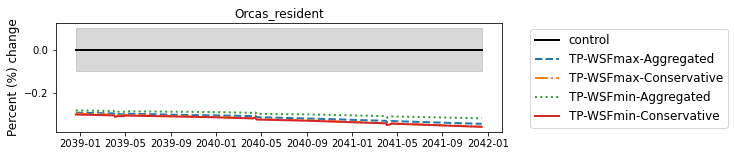

In [62]:
compare_scenario_vertebrates('Orcas_resident')

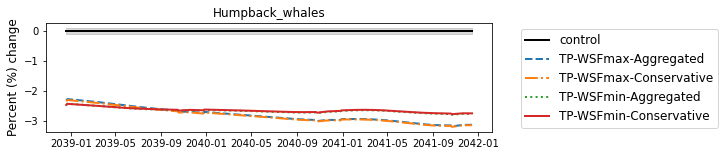

In [63]:
compare_scenario_vertebrates('Humpback_whales')